In [154]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

from scipy.signal import welch
from scipy.stats import skew
from scipy.stats import kurtosis

from pandas.plotting import scatter_matrix

import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# Предобработка

## Структура каталогов

In [70]:
ROOT = Path(".")

for p in sorted(ROOT.glob("experiment*")):
    print(p)

experiment_bicycle
experiment_handphone_1
experiment_handphone_2
experiment_motorbike
experiment_pocketphone_1
experiment_pocketphone_2


## Функция очистки названий столбцов

In [71]:
def clean_columns(df):
    df = df.copy()

    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "", regex=False)
    )

    return df

## Функция чтения одного эксперимента

In [72]:
def load_experiment(exp_dir):
    exp_dir = Path(exp_dir)

    imu = pd.read_csv(exp_dir / "imu.csv")
    pressure = pd.read_csv(exp_dir / "pressure.csv")

    imu = clean_columns(imu)
    pressure = clean_columns(pressure)

    return imu, pressure

## Загрузим все эксперименты

In [73]:
experiments = {
    "motorbike": "two_wheels",
    "bicycle": "two_wheels",

    "handphone_1": "walking",
    "handphone_2": "walking",

    "pocketphone_1": "walking",
    "pocketphone_2": "walking",
}

## Загрузка данных

In [74]:
data = {}

for exp_name, label in experiments.items():

    folder = Path(f"experiment_{exp_name}")

    imu, pressure = load_experiment(folder)

    data[exp_name] = {
        "label": label,
        "imu": imu,
        "pressure": pressure
    }

    print(
        f"{exp_name:15s}",
        f"imu={len(imu):7d}",
        f"pressure={len(pressure):7d}"
    )

motorbike       imu=  27927 pressure=    260
bicycle         imu=  24517 pressure=    228
handphone_1     imu=  18320 pressure=    170
handphone_2     imu=  18424 pressure=    171
pocketphone_1   imu=  18468 pressure=    172
pocketphone_2   imu=  18720 pressure=    174


## Проверка на мусор

In [75]:
for name, exp in data.items():

    print("\n", "=" * 60)
    print(name)

    print("\nIMU")
    print(exp["imu"].info())

    print("\nPressure")
    print(exp["pressure"].info())


motorbike

IMU
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27927 entries, 0 to 27926
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   t_utc[s]    27927 non-null  float64
 1   a_x[m/s2]   27927 non-null  float64
 2   a_y[m/s2]   27927 non-null  float64
 3   a_z[m/s2]   27927 non-null  float64
 4   w_x[rad/s]  27927 non-null  float64
 5   w_y[rad/s]  27927 non-null  float64
 6   w_z[rad/s]  27927 non-null  float64
dtypes: float64(7)
memory usage: 1.5 MB
None

Pressure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   t_utc[s]            260 non-null    float64
 1   pressure[millibar]  260 non-null    float64
dtypes: float64(2)
memory usage: 4.2 KB
None

bicycle

IMU
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24517 entries, 0 to 24516
Data columns (tot

### Проверка NaN

In [76]:
for name, exp in data.items():

    imu_nan = exp["imu"].isna().sum().sum()
    pressure_nan = exp["pressure"].isna().sum().sum()

    print(
        f"{name:15s} "
        f"imu_nan={imu_nan} "
        f"pressure_nan={pressure_nan}"
    )

motorbike       imu_nan=0 pressure_nan=0
bicycle         imu_nan=0 pressure_nan=0
handphone_1     imu_nan=0 pressure_nan=0
handphone_2     imu_nan=0 pressure_nan=0
pocketphone_1   imu_nan=0 pressure_nan=0
pocketphone_2   imu_nan=0 pressure_nan=0


## Проверим временные метки

In [77]:
for name, exp in data.items():

    imu = exp["imu"]

    dt = np.diff(imu["t_utc[s]"])

    print(
        f"{name:15s}",
        f"dt_mean={dt.mean():.4f}",
        f"freq={1/dt.mean():.2f} Hz"
    )

motorbike       dt_mean=0.0100 freq=100.00 Hz
bicycle         dt_mean=0.0100 freq=100.00 Hz
handphone_1     dt_mean=0.0100 freq=100.00 Hz
handphone_2     dt_mean=0.0100 freq=100.00 Hz
pocketphone_1   dt_mean=0.0100 freq=100.00 Hz
pocketphone_2   dt_mean=0.0100 freq=100.00 Hz


## Посмотрим на давление

In [78]:
for name, exp in data.items():

    pressure = exp["pressure"]

    dt = np.diff(pressure["t_utc[s]"])

    print(
        f"{name:15s}",
        f"dt_mean={dt.mean():.3f}",
        f"freq={1/dt.mean():.2f} Hz"
    )

motorbike       dt_mean=1.068 freq=0.94 Hz
bicycle         dt_mean=1.067 freq=0.94 Hz
handphone_1     dt_mean=1.066 freq=0.94 Hz
handphone_2     dt_mean=1.066 freq=0.94 Hz
pocketphone_1   dt_mean=1.066 freq=0.94 Hz
pocketphone_2   dt_mean=1.066 freq=0.94 Hz


## Модуль ускорения

In [79]:
for exp in data.values():

    imu = exp["imu"]

    imu["acc_norm"] = np.sqrt(
        imu["a_x[m/s2]"]**2 +
        imu["a_y[m/s2]"]**2 +
        imu["a_z[m/s2]"]**2
    )

    imu["gyro_norm"] = np.sqrt(
        imu["w_x[rad/s]"]**2 +
        imu["w_y[rad/s]"]**2 +
        imu["w_z[rad/s]"]**2
    )

## Быстрая визуализация

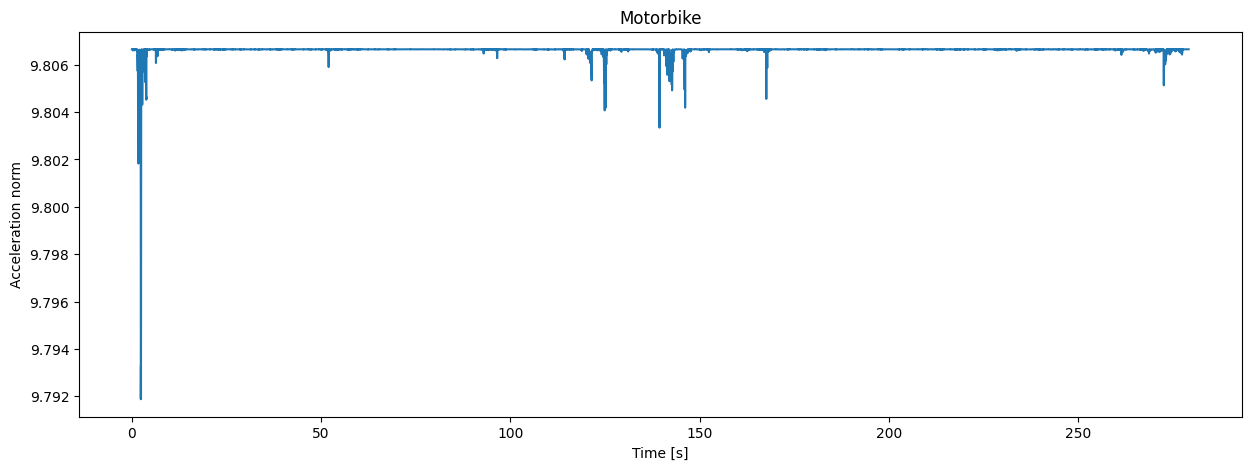

In [80]:
fig, ax = plt.subplots(figsize=(15, 5))

imu = data["motorbike"]["imu"]

ax.plot(
    imu["t_utc[s]"] - imu["t_utc[s]"].iloc[0],
    imu["acc_norm"]
)

ax.set_title("Motorbike")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Acceleration norm")
plt.show()

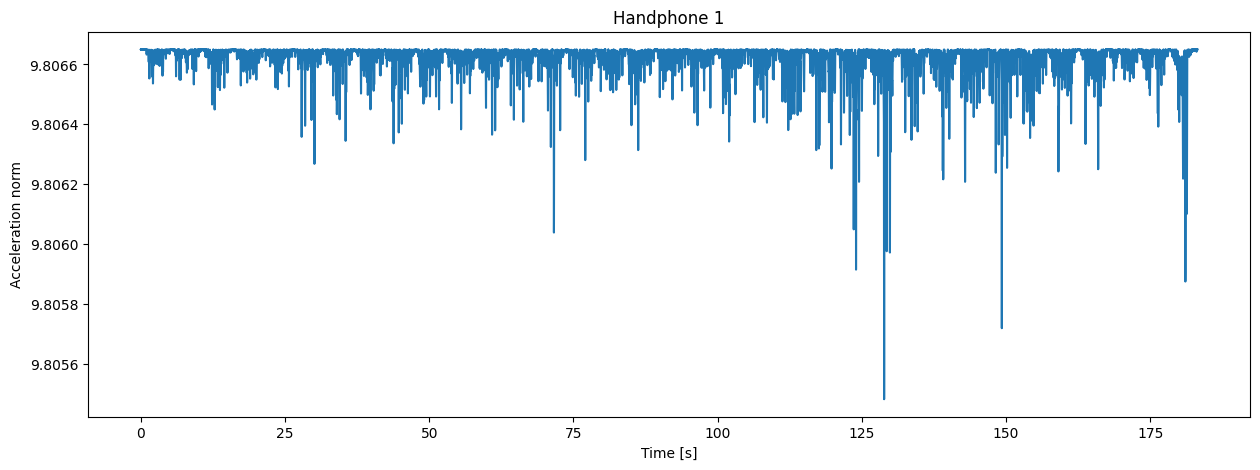

In [81]:
fig, ax = plt.subplots(figsize=(15, 5))

imu = data["handphone_1"]["imu"]

ax.plot(
    imu["t_utc[s]"] - imu["t_utc[s]"].iloc[0],
    imu["acc_norm"]
)

ax.set_title("Handphone 1")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Acceleration norm")
plt.show()

In [82]:
data

{'motorbike': {'label': 'two_wheels',
  'imu':            t_utc[s]  a_x[m/s2]  a_y[m/s2]  a_z[m/s2]  w_x[rad/s]  w_y[rad/s]  \
  0      1.781258e+09  -1.855296  -4.674409  -8.418917   -0.213083   -0.434289   
  1      1.781258e+09  -1.884948  -4.659474  -8.420609   -0.198745   -0.412741   
  2      1.781258e+09  -1.912849  -4.645935  -8.421798   -0.181029   -0.391855   
  3      1.781258e+09  -1.938941  -4.633634  -8.422608   -0.172617   -0.371284   
  4      1.781258e+09  -1.964153  -4.622012  -8.423151   -0.165601   -0.377050   
  ...             ...        ...        ...        ...         ...         ...   
  27922  1.781258e+09  -0.093189  -6.192937  -7.603238   -0.084775   -0.203295   
  27923  1.781258e+09  -0.110815  -6.187866  -7.607127   -0.040490   -0.264275   
  27924  1.781258e+09  -0.129711  -6.188507  -7.606307    0.061593   -0.182681   
  27925  1.781258e+09  -0.141780  -6.195759  -7.600186    0.120481   -0.078277   
  27926  1.781258e+09  -0.143062  -6.196674  -7.59941

## Анализ данных

### Посмотрим длительность экспериментов

In [83]:
for name, exp in data.items():

    imu = exp["imu"]

    duration = (
        imu["t_utc[s]"].iloc[-1]
        - imu["t_utc[s]"].iloc[0]
    )

    print(
        f"{name:15s}",
        f"{duration:.1f} sec"
    )

motorbike       279.3 sec
bicycle         245.2 sec
handphone_1     183.2 sec
handphone_2     184.2 sec
pocketphone_1   184.7 sec
pocketphone_2   187.2 sec


### Нормализуем время

In [84]:
for exp in data.values():

    imu = exp["imu"]
    pressure = exp["pressure"]

    imu["t"] = imu["t_utc[s]"] - imu["t_utc[s]"].iloc[0]
    pressure["t"] = pressure["t_utc[s]"] - pressure["t_utc[s]"].iloc[0]

### Визуально сравним сигналы

In [85]:
def plot_signal(exp_name, seconds=20):

    imu = data[exp_name]["imu"]

    mask = imu["t"] < seconds

    plt.figure(figsize=(15,5))

    plt.plot(
        imu.loc[mask, "t"],
        imu.loc[mask, "acc_norm"]
    )

    plt.title(exp_name)
    plt.xlabel("Time [s]")
    plt.ylabel("Acceleration norm")

    plt.grid(True)
    plt.show()

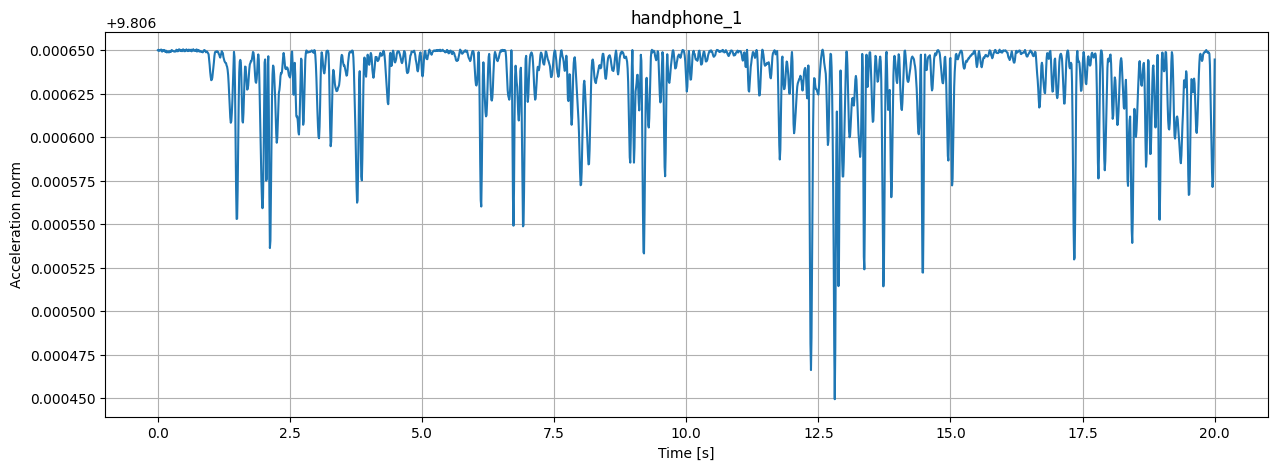

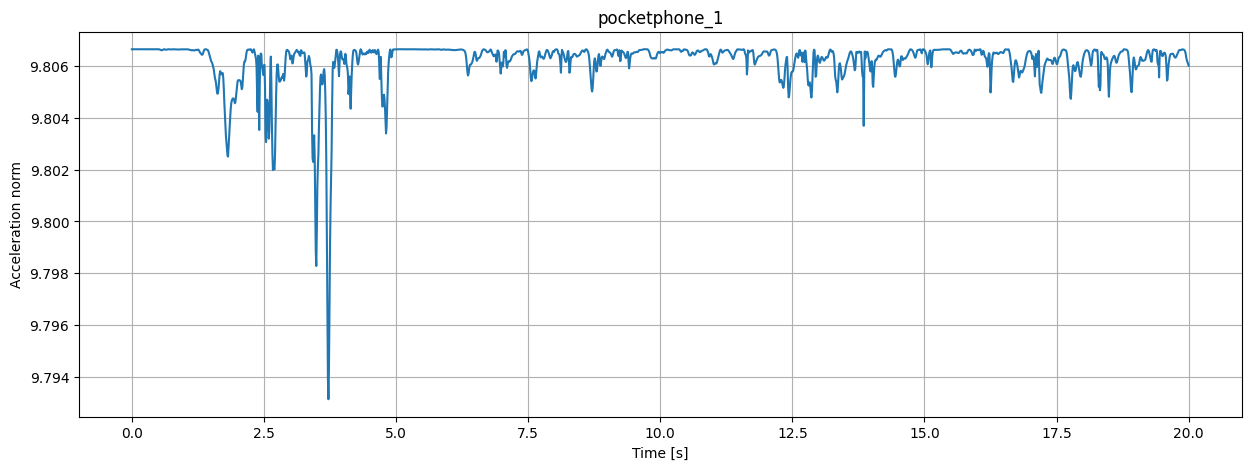

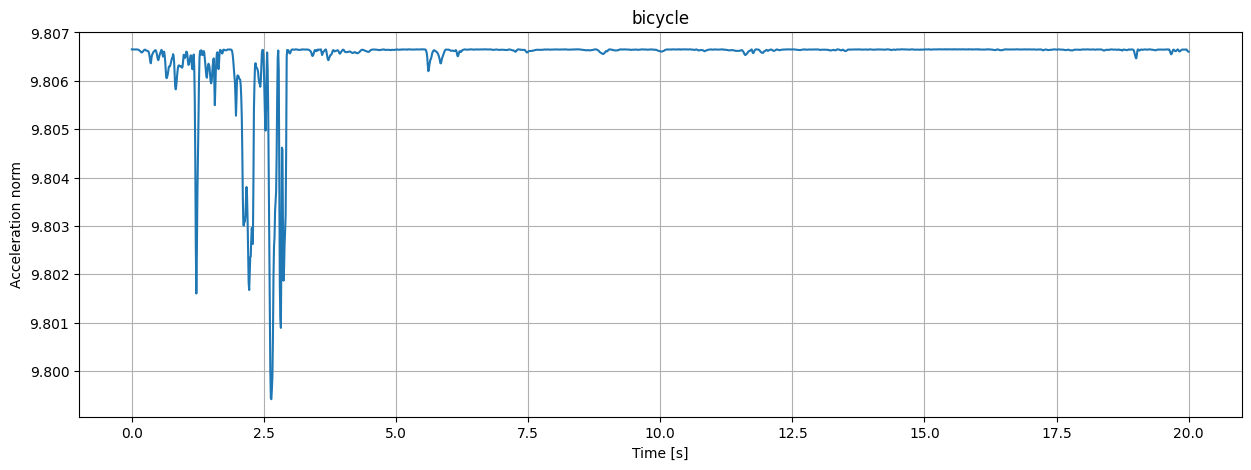

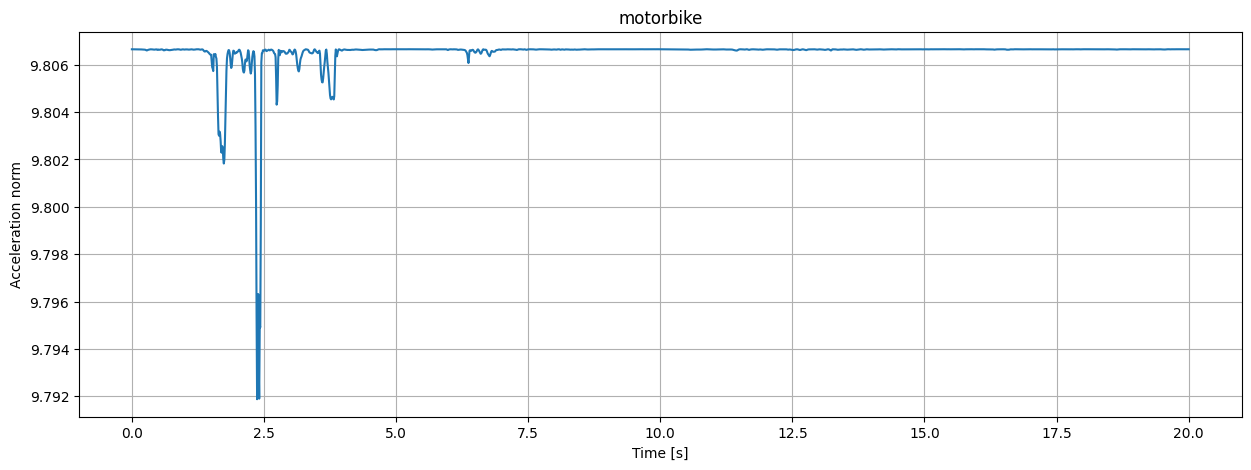

In [86]:
plot_signal("handphone_1")
plot_signal("pocketphone_1")
plot_signal("bicycle")
plot_signal("motorbike")

### Посмотрим спектры

In [87]:
def plot_spectrum(exp_name):

    imu = data[exp_name]["imu"]

    fs = 100

    f, pxx = welch(
        imu["acc_norm"],
        fs=fs,
        nperseg=2048
    )

    plt.figure(figsize=(10,5))

    plt.semilogy(f, pxx)

    plt.title(exp_name)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD")

    plt.grid(True)

    plt.show()

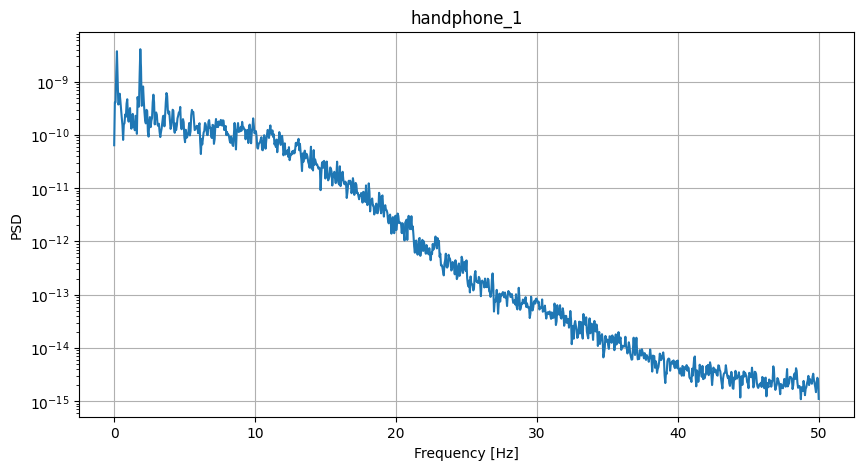

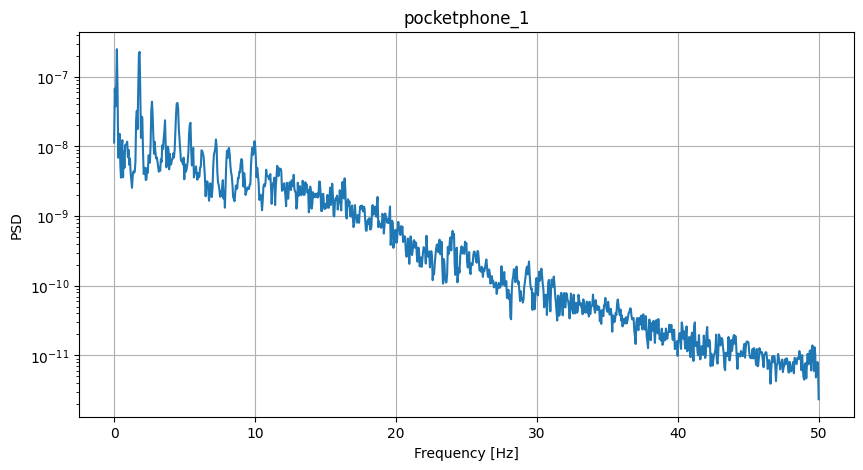

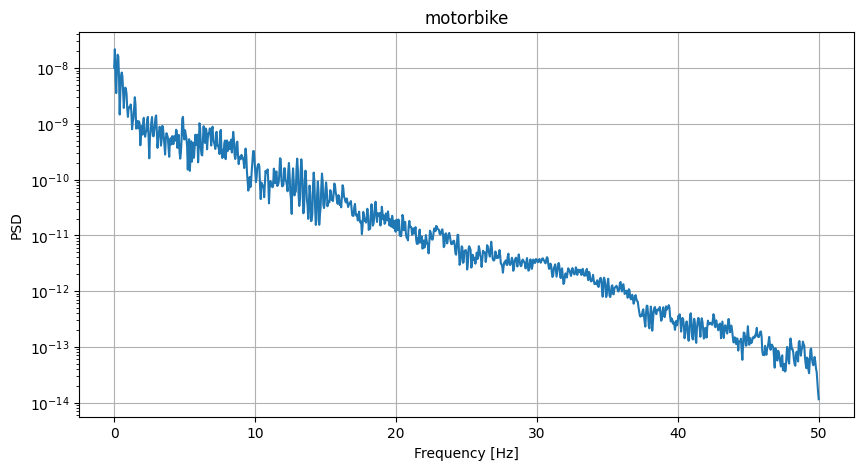

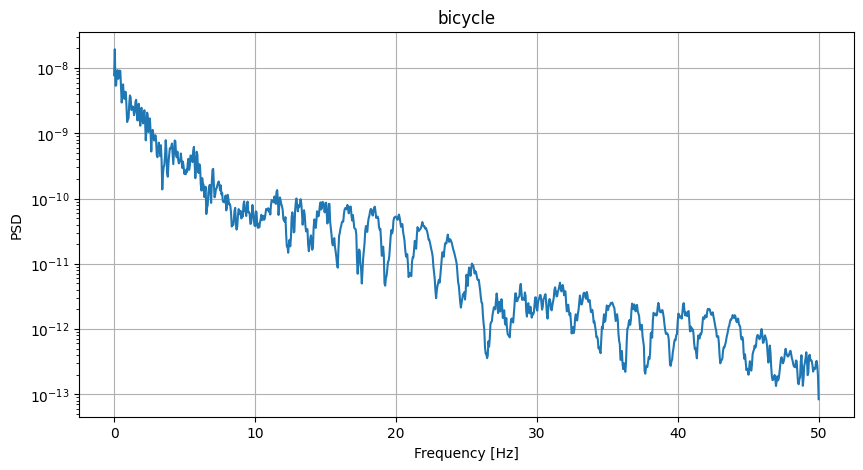

In [88]:
plot_spectrum("handphone_1")
plot_spectrum("pocketphone_1")
plot_spectrum("motorbike")
plot_spectrum("bicycle")

### Разбиваем на окна

In [89]:
WINDOW_SIZE = 1000
STEP_SIZE = 200

### Извлекаем признаки

In [90]:
def extract_features(window):

    x = window["acc_norm"].values

    return {
        "acc_mean": np.mean(x),
        "acc_std": np.std(x),
        "acc_min": np.min(x),
        "acc_max": np.max(x),
        "acc_range": np.ptp(x),
        "acc_skew": skew(x),
        "acc_kurtosis": kurtosis(x),
        "acc_rms": np.sqrt(np.mean(x**2))
    }

### Формируем датасет окон

In [91]:
rows = []

for exp_name, exp in data.items():

    imu = exp["imu"]

    for start in range(
        0,
        len(imu) - WINDOW_SIZE,
        STEP_SIZE
    ):

        stop = start + WINDOW_SIZE

        window = imu.iloc[start:stop]

        feat = extract_features(window)

        feat["experiment"] = exp_name
        feat["label"] = exp["label"]

        rows.append(feat)

dataset = pd.DataFrame(rows)

In [92]:
dataset.head()

,acc_mean,acc_std,acc_min,acc_max,acc_range,acc_skew,acc_kurtosis,acc_rms,experiment,label
0,9.806371,0.001280,9.791876,9.806652,0.014776,-8.019961,72.905822,9.806371,motorbike,two_wheels
1,9.806447,0.001193,9.791876,9.806652,0.014776,-9.617682,98.358499,9.806447,motorbike,two_wheels
2,9.806636,0.000037,9.806071,9.806652,0.000582,-7.975008,86.423782,9.806636,motorbike,two_wheels
3,9.806637,0.000037,9.806071,9.806652,0.000582,-8.066876,87.462557,9.806637,motorbike,two_wheels
4,9.806645,0.000008,9.806594,9.806652,0.000058,-2.541277,9.333795,9.806645,motorbike,two_wheels


### Смотрим разделимость признаков

In [93]:
dataset.groupby("label")[
    ["acc_std", "acc_range", "acc_rms"]
].mean()

,acc_std,acc_range,acc_rms
label,,,
two_wheels,0.000067,0.000697,9.806627
walking,0.000215,0.001848,9.806494


### Быстрая визуализация

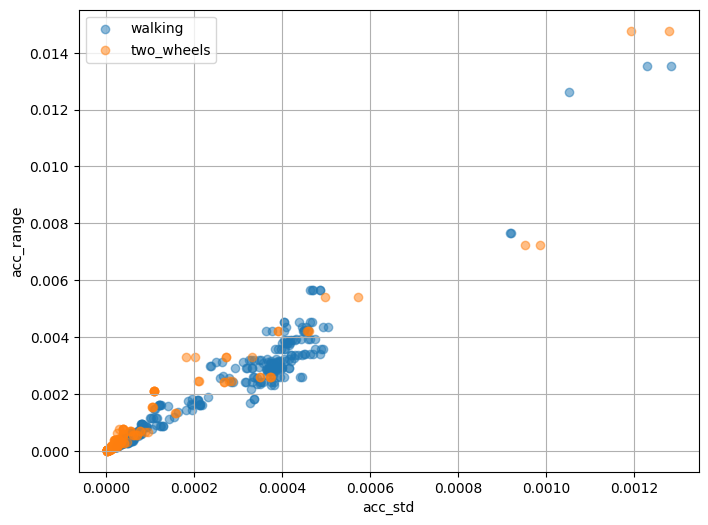

In [94]:
walking = dataset[
    dataset.label == "walking"
]

two_wheels = dataset[
    dataset.label == "two_wheels"
]

plt.figure(figsize=(8,6))

plt.scatter(
    walking["acc_std"],
    walking["acc_range"],
    alpha=0.5,
    label="walking"
)

plt.scatter(
    two_wheels["acc_std"],
    two_wheels["acc_range"],
    alpha=0.5,
    label="two_wheels"
)

plt.xlabel("acc_std")
plt.ylabel("acc_range")

plt.legend()
plt.grid(True)

plt.show()

### Убрать гравитацию

In [95]:
for exp in data.values():

    imu = exp["imu"]

    imu["acc_dyn"] = (
        imu["acc_norm"]
        - imu["acc_norm"].rolling(
            200,
            center=True,
            min_periods=1
        ).mean()
    )

### Посмотреть новый сигнал

In [96]:
def plot_dynamic(exp_name, seconds=20):

    imu = data[exp_name]["imu"]

    mask = imu["t"] < seconds

    plt.figure(figsize=(15,4))

    plt.plot(
        imu.loc[mask, "t"],
        imu.loc[mask, "acc_dyn"]
    )

    plt.grid()
    plt.title(exp_name)
    plt.show()

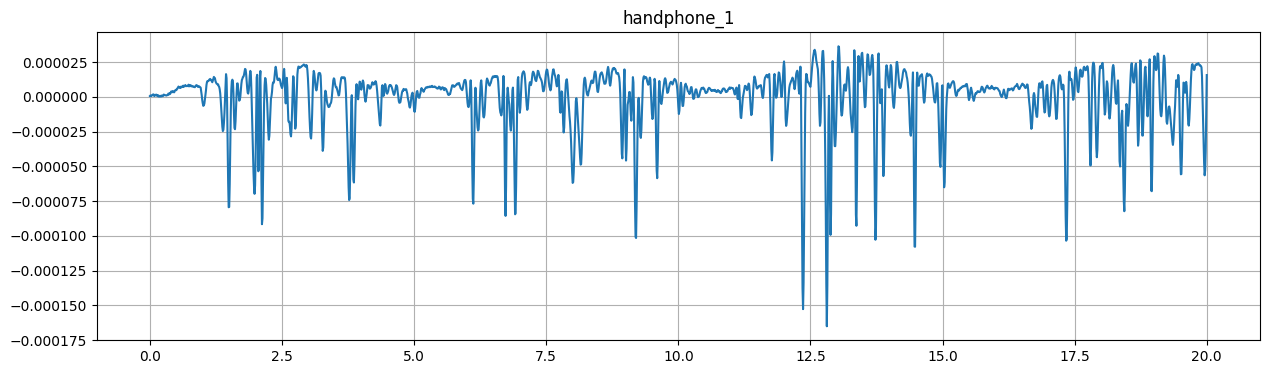

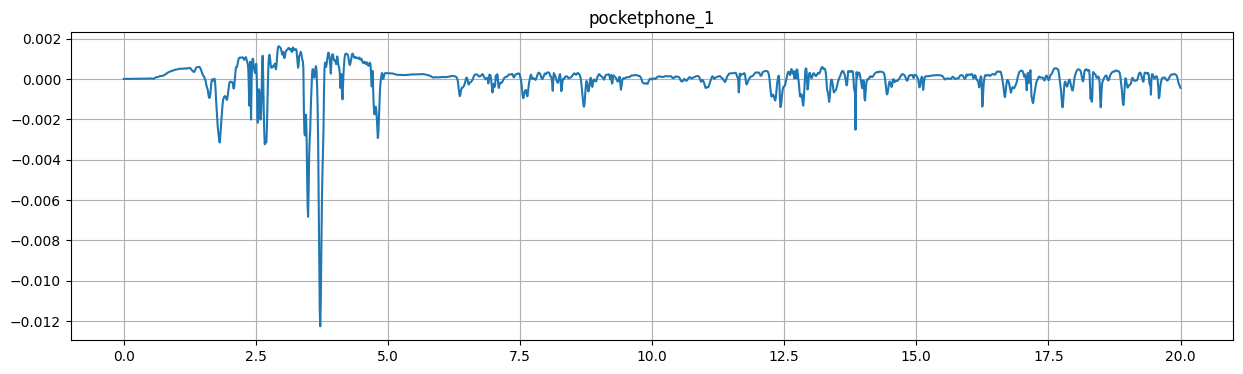

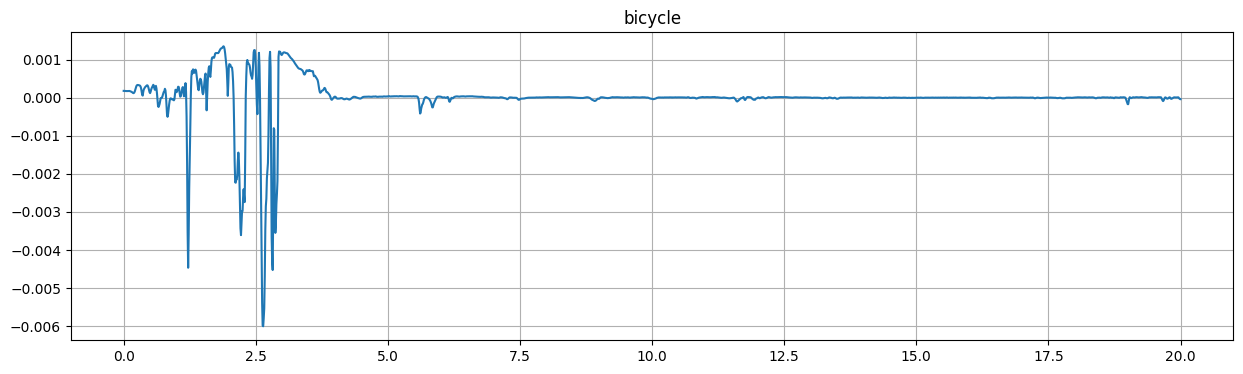

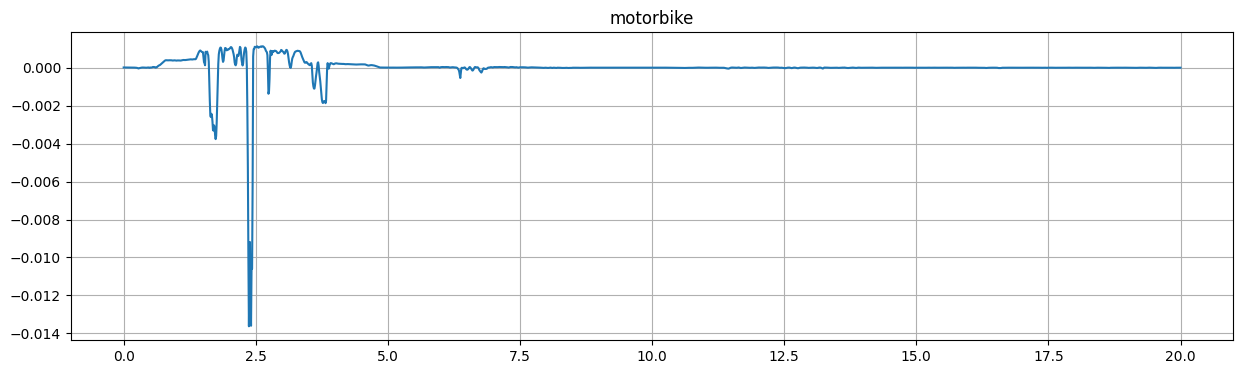

In [97]:
plot_dynamic("handphone_1")
plot_dynamic("pocketphone_1")
plot_dynamic("bicycle")
plot_dynamic("motorbike")

### Проанализируем изменённые данные

In [98]:
def plot_spectrum(exp_name):

    imu = data[exp_name]["imu"]

    fs = 100

    f, pxx = welch(
        imu["acc_dyn"],
        fs=fs,
        nperseg=2048
    )

    plt.figure(figsize=(10,5))

    plt.semilogy(f, pxx)

    plt.title(exp_name)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD")

    plt.grid(True)

    plt.show()

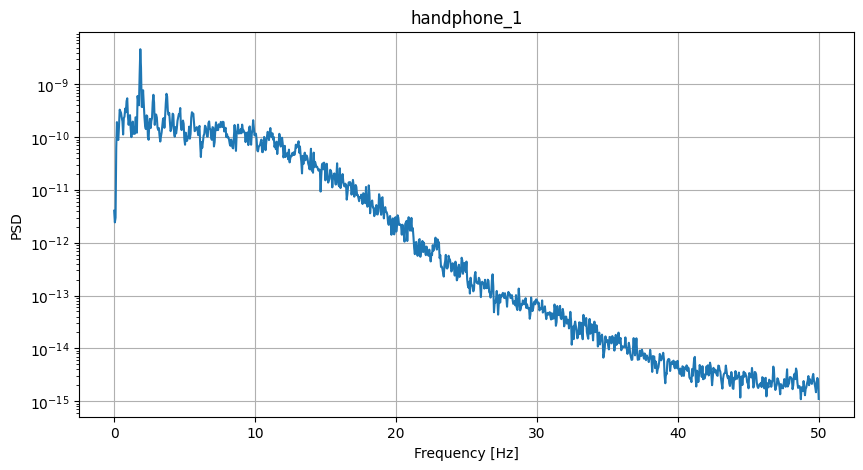

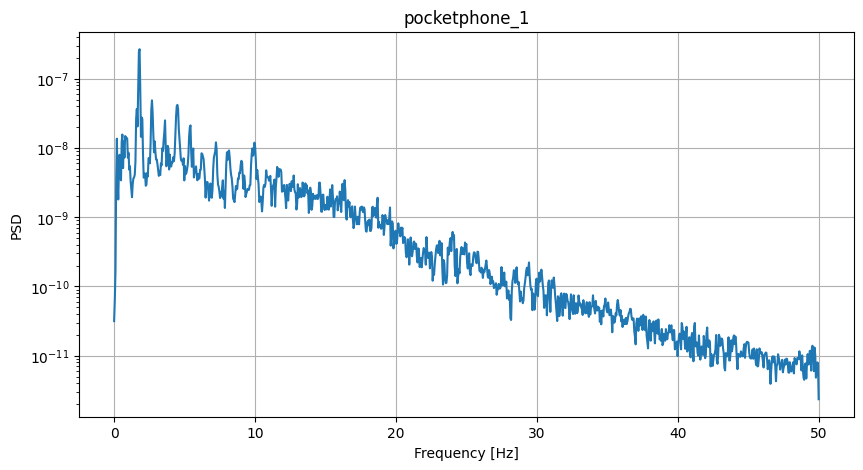

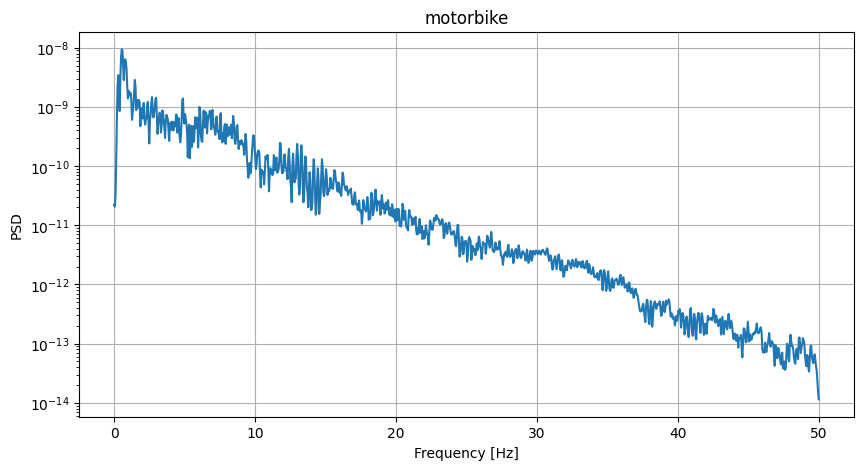

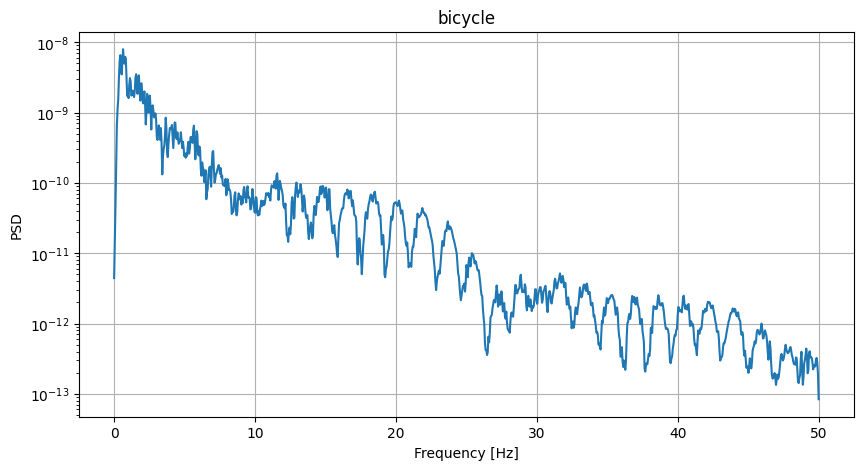

In [99]:
plot_spectrum("handphone_1")
plot_spectrum("pocketphone_1")
plot_spectrum("motorbike")
plot_spectrum("bicycle")

## Посмотрим гироскоп

In [100]:
def plot_gyro(exp_name, seconds=20):

    imu = data[exp_name]["imu"]

    mask = imu["t"] < seconds

    plt.figure(figsize=(15,4))

    plt.plot(
        imu.loc[mask, "t"],
        imu.loc[mask, "gyro_norm"]
    )

    plt.grid()
    plt.title(exp_name)
    plt.show()

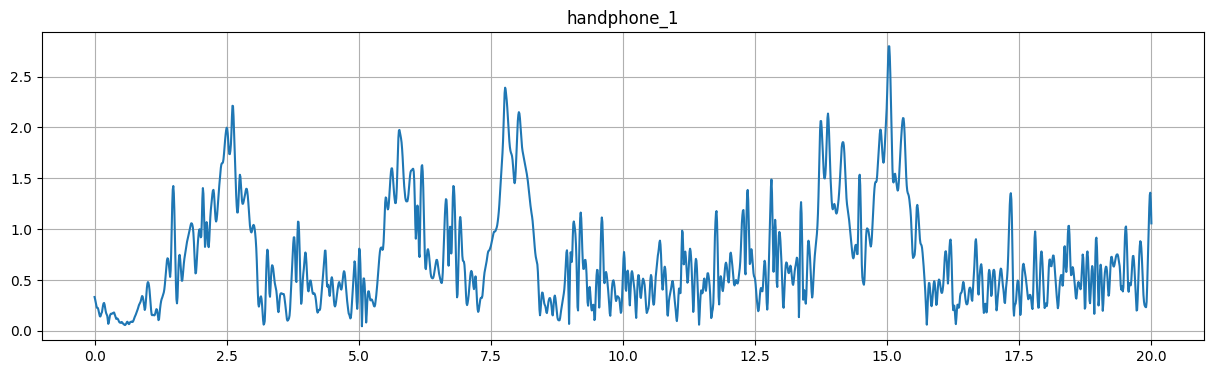

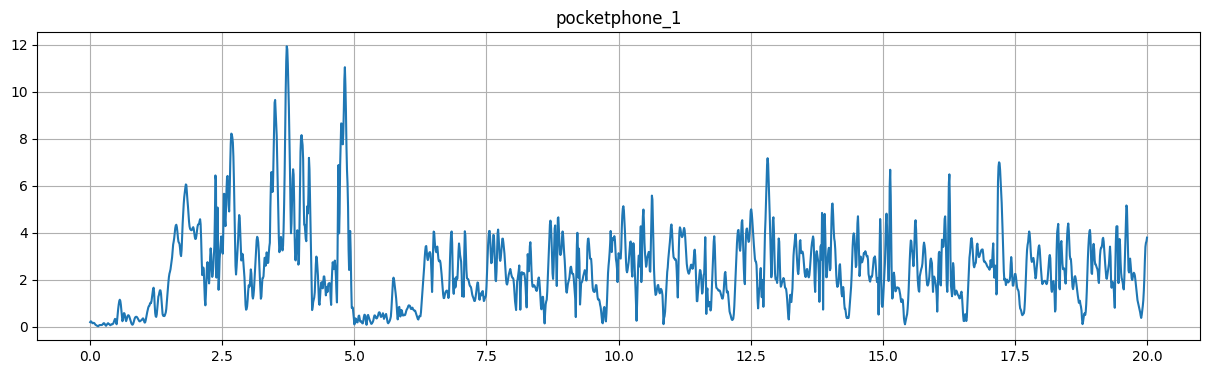

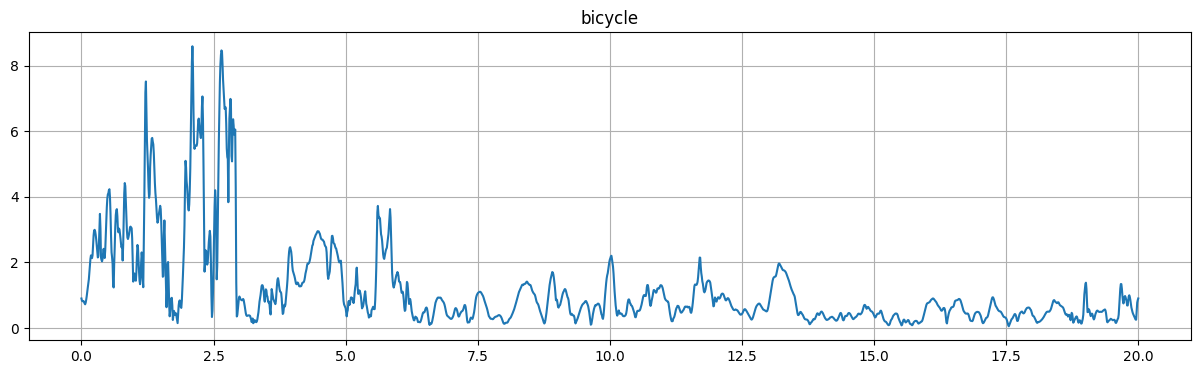

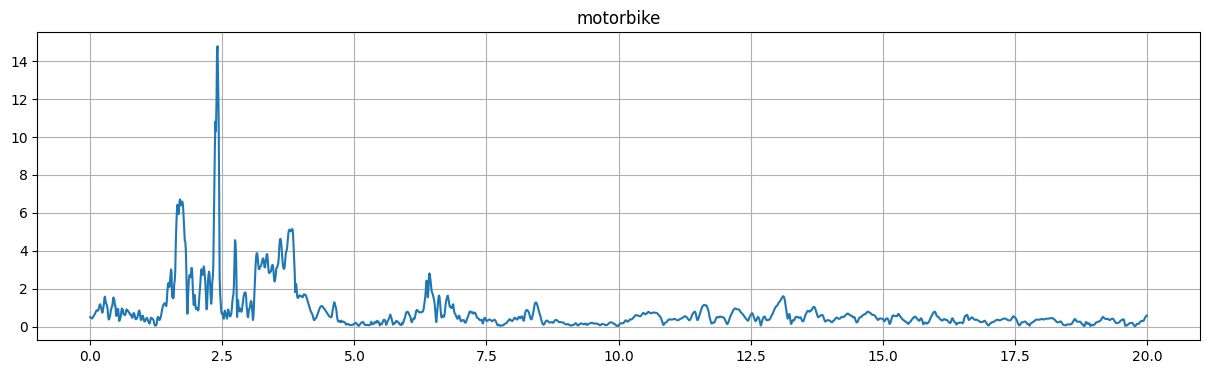

In [101]:
plot_gyro("handphone_1")
plot_gyro("pocketphone_1")
plot_gyro("bicycle")
plot_gyro("motorbike")

### Пересоберём датасет, добавим новые признаки

In [102]:
FS = 100

def extract_features(window):

    x = window["acc_dyn"].values

    features = {}

    # Временная область
    features["acc_mean"] = np.mean(x)
    features["acc_std"] = np.std(x)
    features["acc_rms"] = np.sqrt(np.mean(x**2))
    features["acc_range"] = np.ptp(x)

    # Спектр
    f, pxx = welch(
        x,
        fs=FS,
        nperseg=min(len(x), 512)
    )

    features["spectral_energy"] = np.sum(pxx)

    # Доминирующая частота
    features["dominant_freq"] = f[np.argmax(pxx)]

    # Энергия шагов
    step_band = (f >= 1) & (f <= 3)

    features["energy_1_3Hz"] = np.sum(pxx[step_band])

    # Высокочастотная энергия
    high_band = (f >= 10)

    features["energy_10Hz+"] = np.sum(pxx[high_band])

    return features

In [103]:
rows = []

for exp_name, exp in data.items():

    imu = exp["imu"]

    for start in range(
        0,
        len(imu) - WINDOW_SIZE,
        STEP_SIZE
    ):

        stop = start + WINDOW_SIZE

        window = imu.iloc[start:stop]

        feat = extract_features(window)

        feat["experiment"] = exp_name
        feat["label"] = exp["label"]

        rows.append(feat)

dataset = pd.DataFrame(rows)

print(dataset.shape)
dataset.head()

(605, 10)


,acc_mean,acc_std,acc_rms,acc_range,spectral_energy,dominant_freq,energy_1_3Hz,energy_10Hz+,experiment,label
0,1.137639e-06,0.001194,0.001194,0.014759,1.727139e-05,1.562500,7.359348e-06,8.724000e-07,motorbike,two_wheels
1,-1.552978e-05,0.001121,0.001122,0.014759,5.111783e-07,0.781250,1.494387e-07,1.859654e-08,motorbike,two_wheels
2,1.406960e-05,0.000058,0.000060,0.000772,1.709718e-08,0.195312,2.194803e-09,2.315224e-09,motorbike,two_wheels
3,-1.368519e-06,0.000033,0.000033,0.000580,7.444977e-10,0.585938,1.524600e-10,4.283942e-11,motorbike,two_wheels
4,-6.358491e-08,0.000007,0.000007,0.000058,3.598563e-10,6.640625,8.794671e-11,3.415645e-11,motorbike,two_wheels


### Новый scatter

In [104]:
def plot_features(x_col, y_col):

    plt.figure(figsize=(8, 6))

    for label in dataset["label"].unique():

        subset = dataset[
            dataset["label"] == label
        ]

        plt.scatter(
            subset[x_col],
            subset[y_col],
            alpha=0.6,
            label=label
        )

    plt.xlabel(x_col)
    plt.ylabel(y_col)

    plt.legend()
    plt.grid(True)

    plt.show()

### Попарно отрисуем признаки и попытаемся найти лучшее разделение

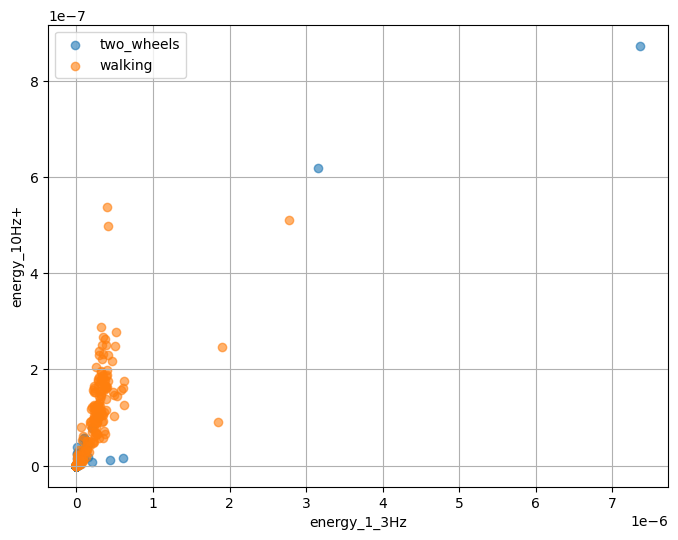

In [105]:
plot_features(
    "energy_1_3Hz",
    "energy_10Hz+"
)

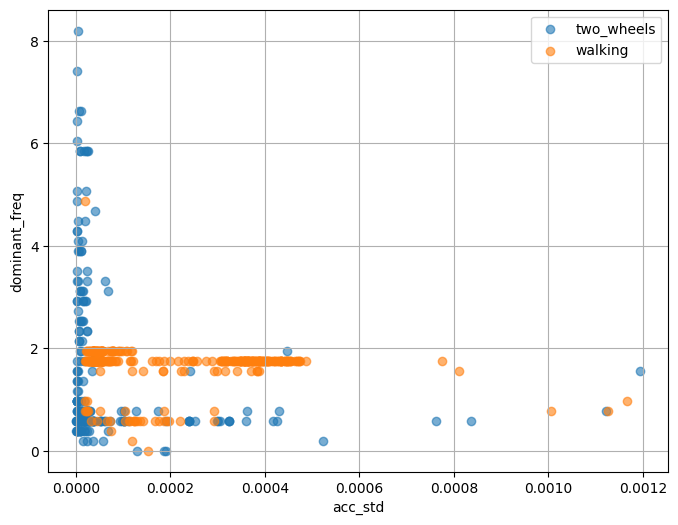

In [106]:
plot_features(
    "acc_std",
    "dominant_freq"
)

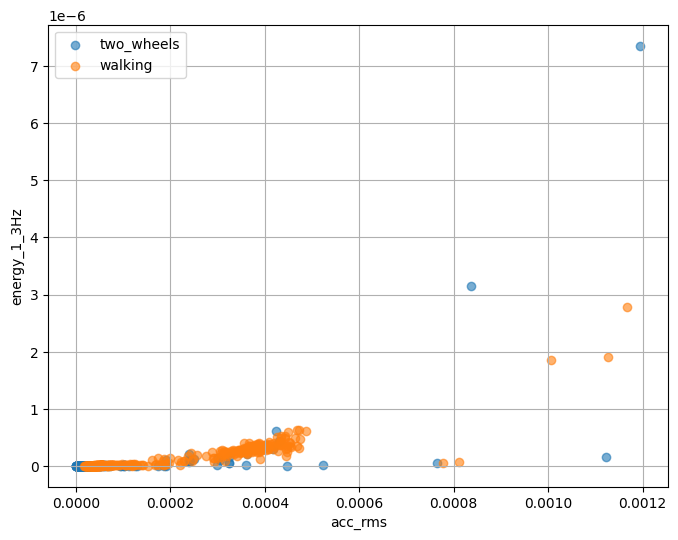

In [107]:
plot_features(
    "acc_rms",
    "energy_1_3Hz"
)

### Посмотрим вообще всё

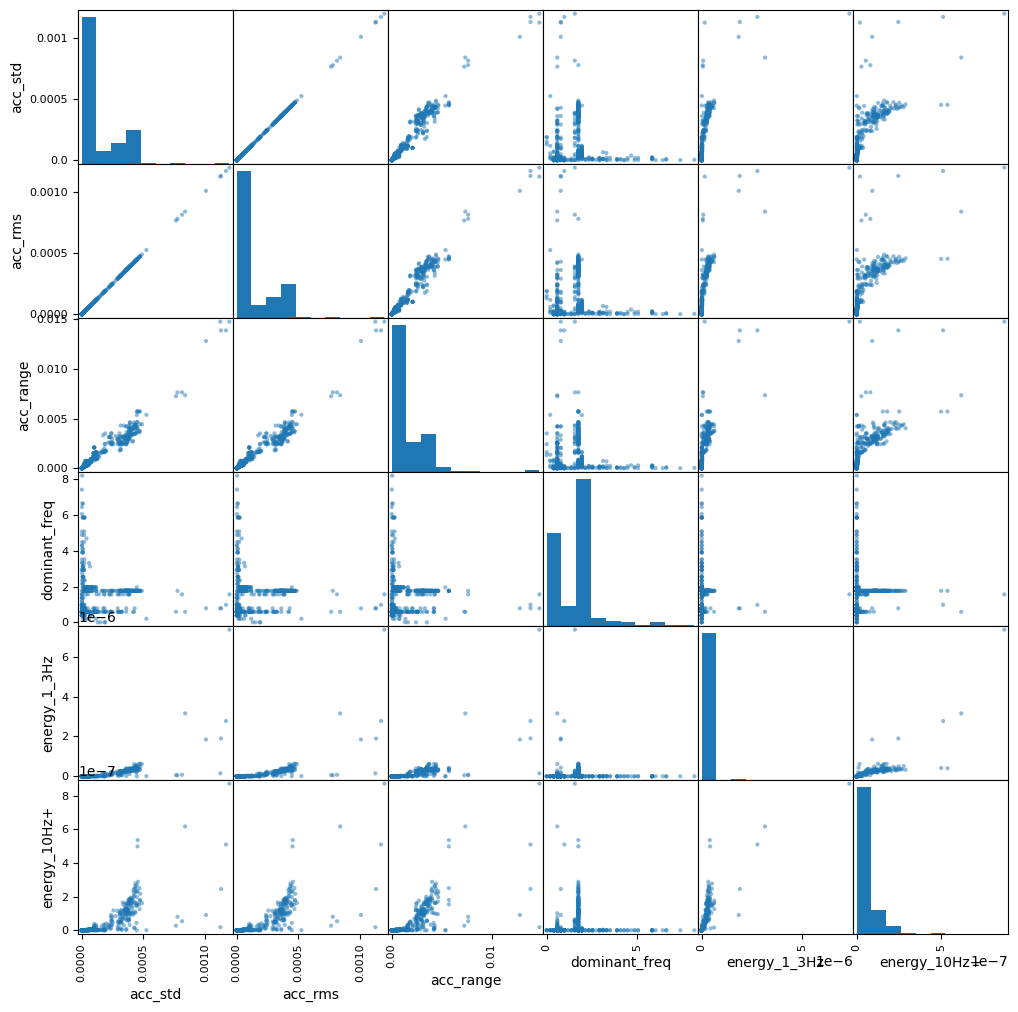

In [108]:
cols = [
    "acc_std",
    "acc_rms",
    "acc_range",
    "dominant_freq",
    "energy_1_3Hz",
    "energy_10Hz+"
]

scatter_matrix(
    dataset[cols],
    figsize=(12, 12),
    diagonal="hist"
)

plt.show()

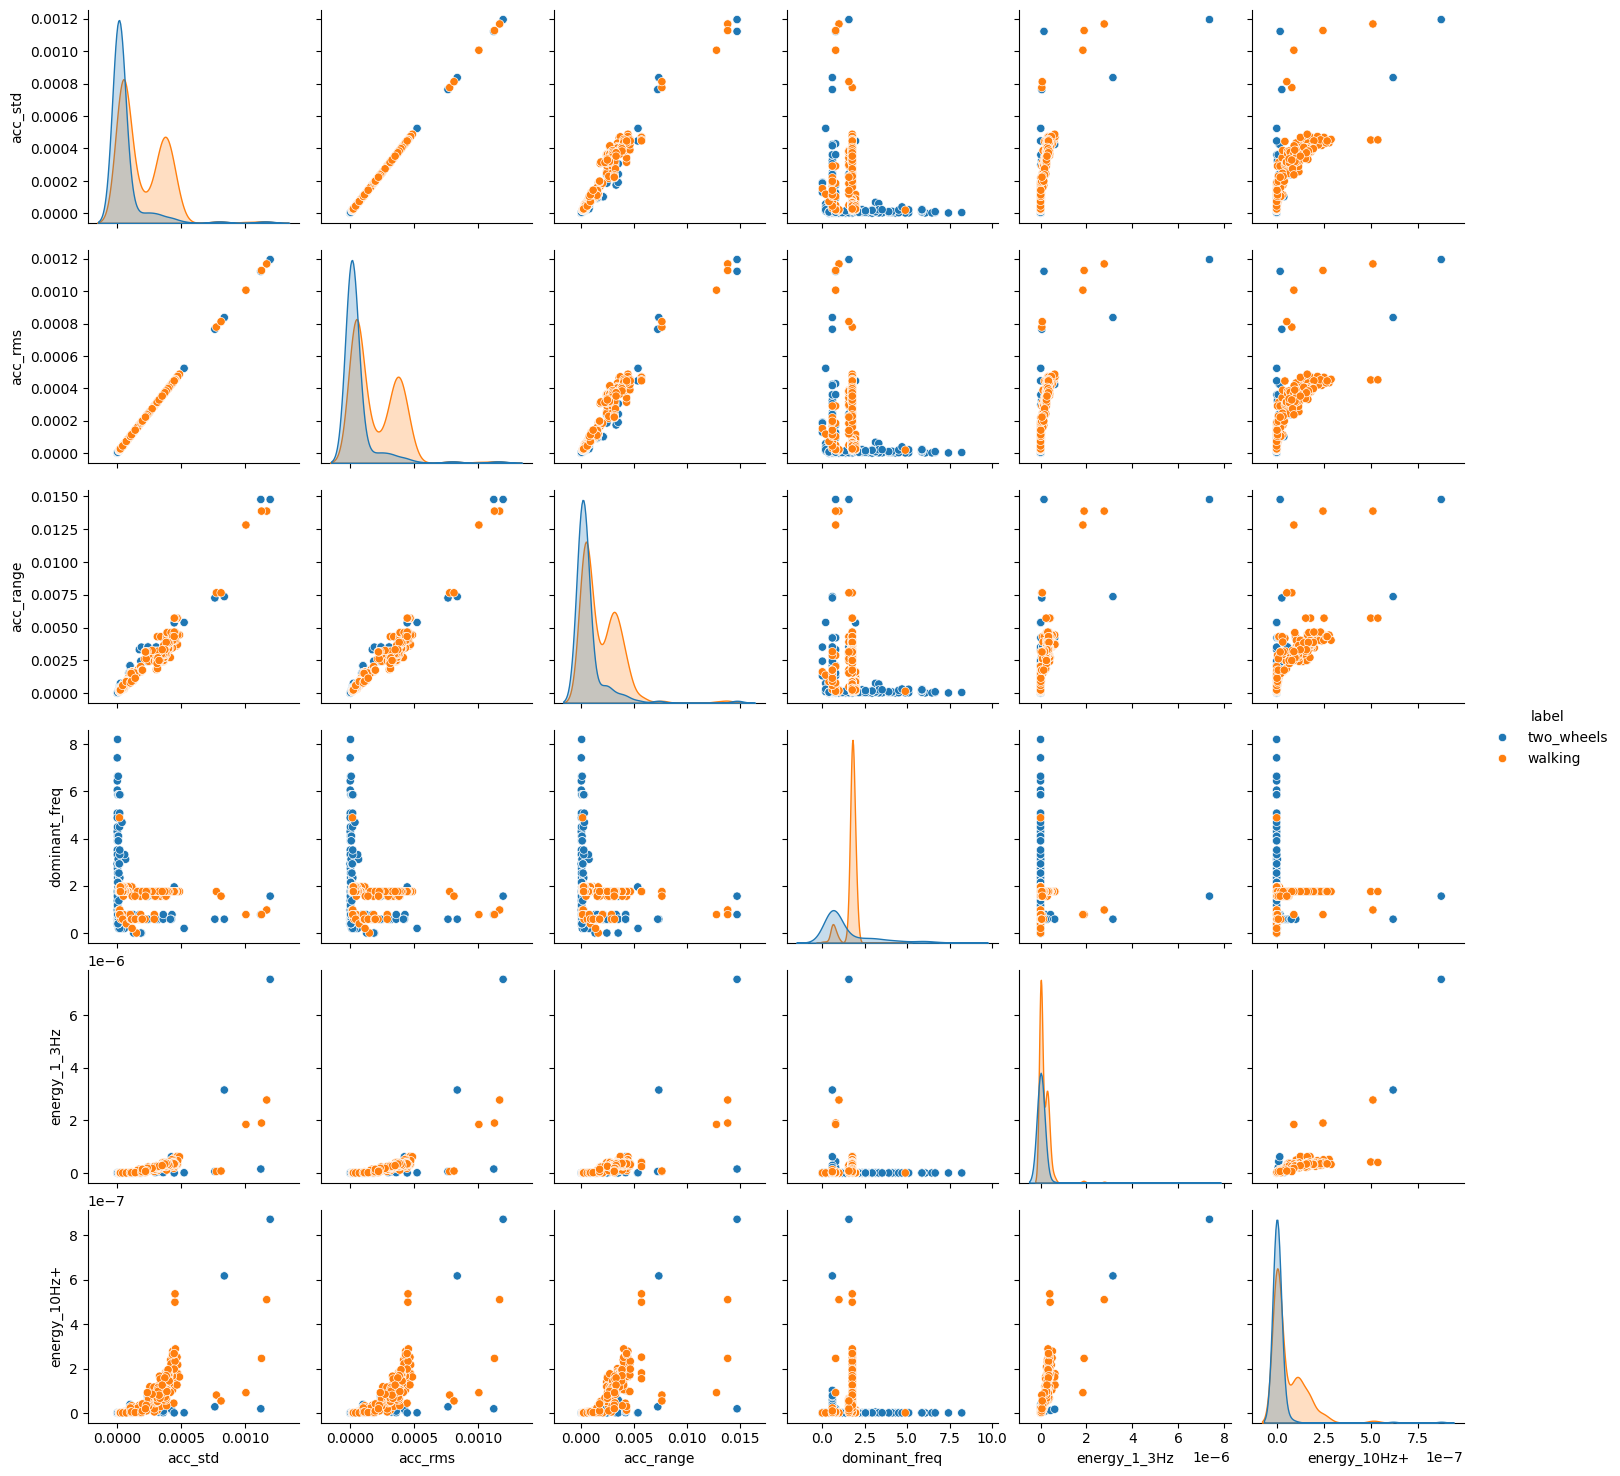

In [109]:
sns.pairplot(
    dataset[
        cols + ["label"]
    ],
    hue="label"
)

plt.show()

## Тяжело

### Подготовка данных

In [110]:
X = dataset.drop(
    columns=["label", "experiment"]
)

y = dataset["label"]

### Преобразуем метки классов в числа

In [111]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'two_wheels': np.int64(0), 'walking': np.int64(1)}


### Обучаем Random Forest

In [112]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y_encoded)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Извлекаем важность признаков

In [113]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
7,energy_10Hz+,0.193983
5,dominant_freq,0.164762
2,acc_rms,0.150205
6,energy_1_3Hz,0.143672
1,acc_std,0.135245
4,spectral_energy,0.120315
3,acc_range,0.066136
0,acc_mean,0.025682


### Визуализация

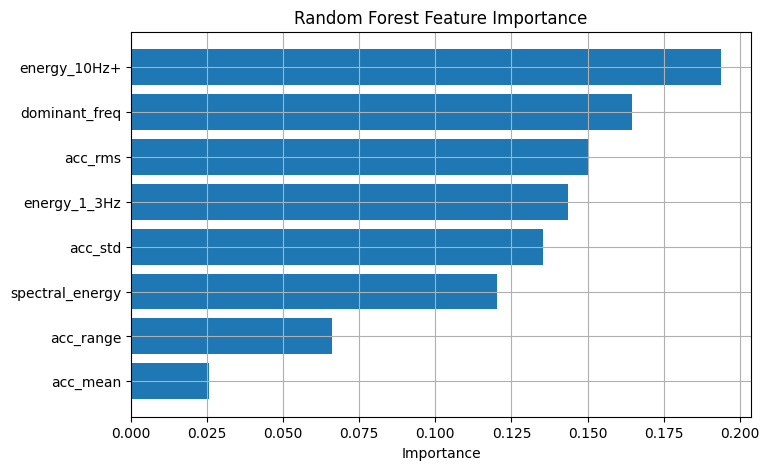

In [114]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.grid(True)

plt.show()

### Проверка качества классификации

In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print(
    classification_report(
        y_test,
        pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

  two_wheels       0.90      0.99      0.94        76
     walking       0.99      0.92      0.96       106

    accuracy                           0.95       182
   macro avg       0.95      0.96      0.95       182
weighted avg       0.95      0.95      0.95       182



### Ого

#### А теперь посмотрим важность признаков

In [116]:
importance.head(20)

,feature,importance
7,energy_10Hz+,0.193983
5,dominant_freq,0.164762
2,acc_rms,0.150205
6,energy_1_3Hz,0.143672
1,acc_std,0.135245
4,spectral_energy,0.120315
3,acc_range,0.066136
0,acc_mean,0.025682


### Матрица корреляций, точно! Почему я не сделал этого раньше...

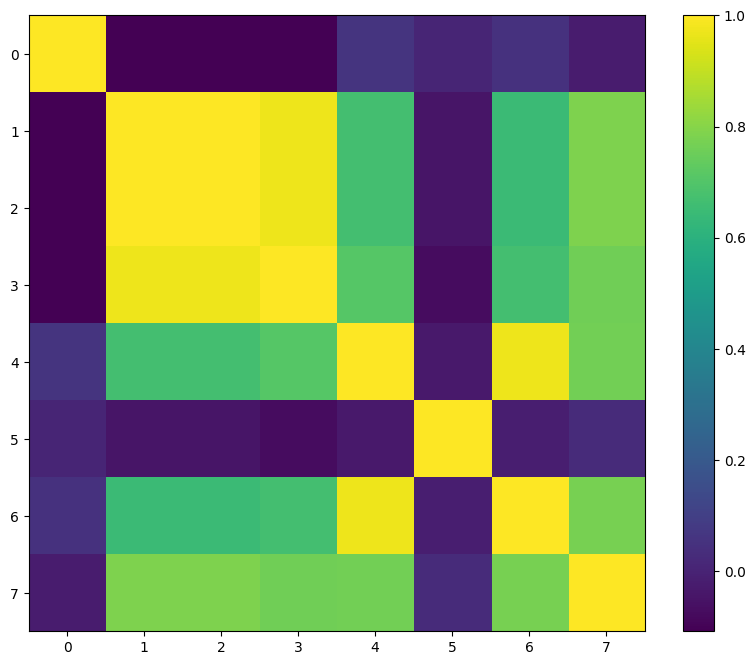

In [117]:
corr = dataset.drop(
    columns=["label", "experiment"]
).corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.show()

### Проверим разделимость

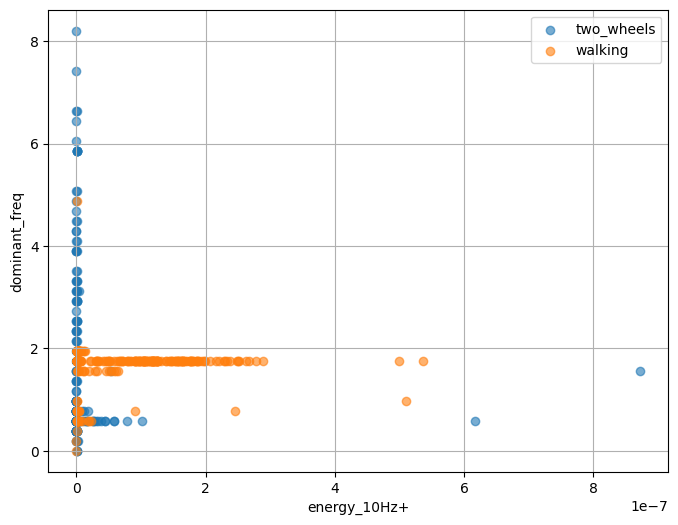

In [118]:
plot_features(
    "energy_10Hz+",
    "dominant_freq"
)

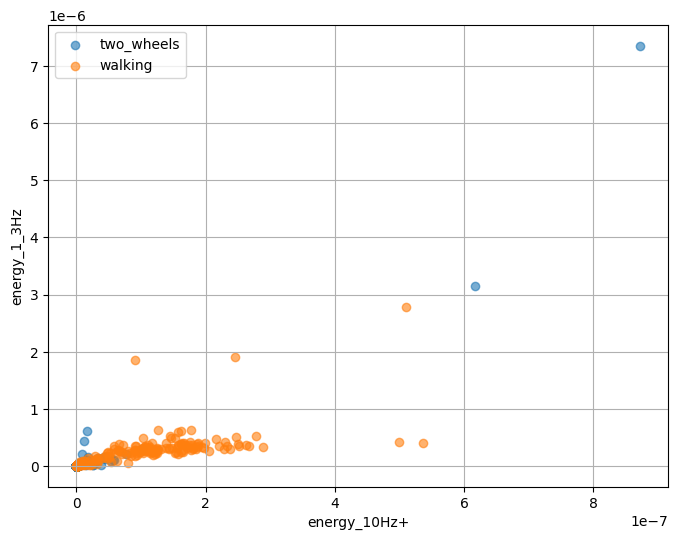

In [119]:
plot_features(
    "energy_10Hz+",
    "energy_1_3Hz"
)

## Теперь перестанем страдать ерундой и создадим жизнеспособное решение

### Универсальная функция для вычисления спектральных признаков

In [120]:
FS = 100

def spectral_features(x):

    f, pxx = welch(
        x,
        fs=FS,
        nperseg=min(len(x), 512)
    )

    dom_freq = f[np.argmax(pxx)]

    energy_total = np.sum(pxx)

    energy_1_3 = np.sum(
        pxx[(f >= 1) & (f <= 3)]
    )

    energy_10 = np.sum(
        pxx[f >= 10]
    )

    return {
        "dominant_freq": dom_freq,
        "spectral_energy": energy_total,
        "energy_1_3Hz": energy_1_3,
        "energy_10Hz+": energy_10
    }

### Добавляем признаки гироскопа

In [121]:
def extract_features(window):

    acc = window["acc_dyn"].values
    gyro = window["gyro_norm"].values

    features = {}

    # -------------------
    # Accelerometer
    # -------------------

    features["acc_std"] = np.std(acc)
    features["acc_rms"] = np.sqrt(np.mean(acc**2))
    features["acc_range"] = np.ptp(acc)
    features["acc_skew"] = skew(acc)
    features["acc_kurtosis"] = kurtosis(acc)

    acc_spec = spectral_features(acc)

    for k, v in acc_spec.items():
        features[f"acc_{k}"] = v

    # -------------------
    # Gyroscope
    # -------------------

    features["gyro_std"] = np.std(gyro)
    features["gyro_rms"] = np.sqrt(np.mean(gyro**2))
    features["gyro_range"] = np.ptp(gyro)
    features["gyro_skew"] = skew(gyro)
    features["gyro_kurtosis"] = kurtosis(gyro)

    gyro_spec = spectral_features(gyro)

    for k, v in gyro_spec.items():
        features[f"gyro_{k}"] = v

    return features

In [122]:
rows = []

for exp_name, exp in data.items():

    imu = exp["imu"]

    for start in range(
        0,
        len(imu) - WINDOW_SIZE,
        STEP_SIZE
    ):

        stop = start + WINDOW_SIZE

        window = imu.iloc[start:stop]

        feat = extract_features(window)

        feat["experiment"] = exp_name
        feat["label"] = exp["label"]

        rows.append(feat)

dataset = pd.DataFrame(rows)

print(dataset.shape)
dataset.head()

(605, 20)


,acc_std,acc_rms,acc_range,acc_skew,acc_kurtosis,acc_dominant_freq,acc_spectral_energy,acc_energy_1_3Hz,acc_energy_10Hz+,gyro_std,gyro_rms,gyro_range,gyro_skew,gyro_kurtosis,gyro_dominant_freq,gyro_spectral_energy,gyro_energy_1_3Hz,gyro_energy_10Hz+,experiment,label
0,0.001194,0.001194,0.014759,-7.711124,71.758646,1.562500,1.727139e-05,7.359348e-06,8.724000e-07,1.615767,1.976912,14.750258,3.633642,19.164414,0.195312,20.609351,7.203638,0.548196,motorbike,two_wheels
1,0.001121,0.001122,0.014759,-9.006233,91.824028,0.781250,5.111783e-07,1.494387e-07,1.859654e-08,1.457604,1.740206,14.750258,4.587369,30.244384,0.195312,5.519116,0.549283,0.057713,motorbike,two_wheels
2,0.000058,0.000060,0.000772,-0.073003,15.341530,0.195312,1.709718e-08,2.194803e-09,2.315224e-09,0.403166,0.651768,2.772164,1.728747,4.291073,0.390625,1.081147,0.228883,0.038810,motorbike,two_wheels
3,0.000033,0.000033,0.000580,-8.392490,100.922466,0.585938,7.444977e-10,1.524600e-10,4.283942e-11,0.363245,0.626174,2.770693,2.048628,6.880943,0.195312,0.411156,0.091949,0.003905,motorbike,two_wheels
4,0.000007,0.000007,0.000058,-2.555049,11.432874,6.640625,3.598563e-10,8.794671e-11,3.415645e-11,0.263427,0.508374,1.563663,1.257522,2.243805,1.367188,0.440201,0.210674,0.004947,motorbike,two_wheels


### Подготовка данных

In [123]:
X = dataset.drop(
    columns=[
        "label",
        "experiment"
    ]
)

y = dataset["label"]

groups = dataset["experiment"]

le = LabelEncoder()

y_encoded = le.fit_transform(y)

## Leave-One-Experiment-Out

In [124]:
logo = LeaveOneGroupOut()

### Оценка качества

In [125]:
scores = []

for train_idx, test_idx in logo.split(
    X,
    y_encoded,
    groups
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y_encoded[train_idx]
    y_test = y_encoded[test_idx]

    test_exp = groups.iloc[test_idx].iloc[0]

    clf = RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )

    clf.fit(X_train, y_train)

    pred = clf.predict(X_test)

    acc = accuracy_score(
        y_test,
        pred
    )

    scores.append(acc)

    print(
        f"{test_exp:15s} "
        f"accuracy = {acc:.3f}"
    )

    cm = confusion_matrix(y_test, pred)

    print(test_exp)
    print(cm)
    print('------------------------')

print()
print("Mean accuracy =", np.mean(scores))
print("Std accuracy  =", np.std(scores))

bicycle         accuracy = 0.661
bicycle
[[78 40]
 [ 0  0]]
------------------------
handphone_1     accuracy = 0.931
handphone_1
[[ 0  0]
 [ 6 81]]
------------------------
handphone_2     accuracy = 0.898
handphone_2
[[ 0  0]
 [ 9 79]]
------------------------
motorbike       accuracy = 0.867
motorbike
[[117  18]
 [  0   0]]
------------------------
pocketphone_1   accuracy = 0.966
pocketphone_1
[[ 0  0]
 [ 3 85]]
------------------------
pocketphone_2   accuracy = 0.910
pocketphone_2
[[ 0  0]
 [ 8 81]]
------------------------

Mean accuracy = 0.8720778036274592
Std accuracy  = 0.09913012314744293


### Обучим Random Forest

In [126]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y_encoded)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [127]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(20)

,feature,importance
17,gyro_energy_10Hz+,0.175843
8,acc_energy_10Hz+,0.119616
5,acc_dominant_freq,0.095970
7,acc_energy_1_3Hz,0.094715
1,acc_rms,0.074883
0,acc_std,0.069260
6,acc_spectral_energy,0.067303
12,gyro_skew,0.047081
3,acc_skew,0.038202
10,gyro_rms,0.035597


### Посмотрим

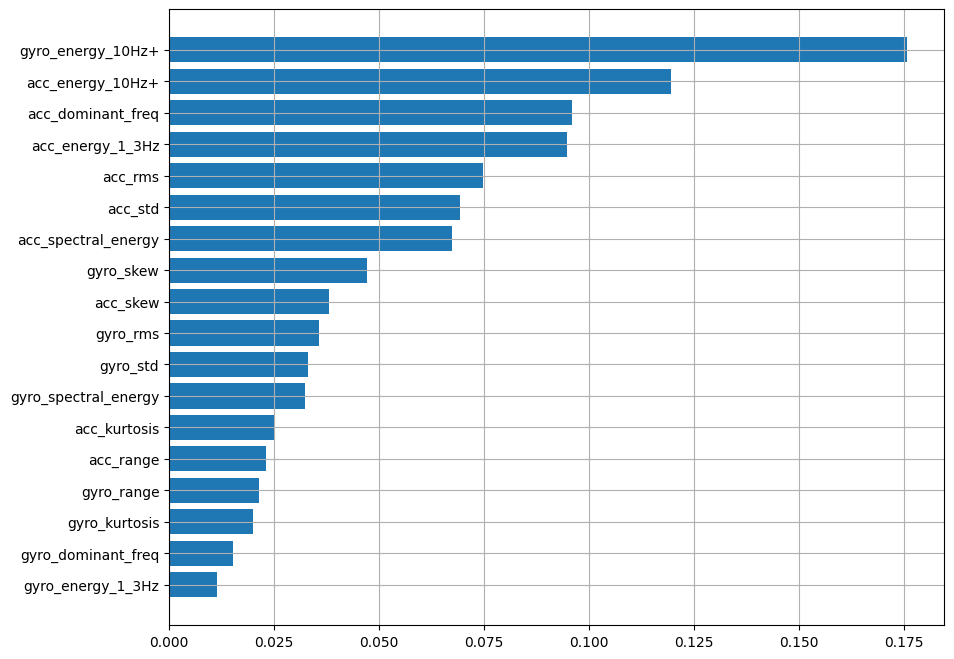

In [128]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["feature"][:20],
    importance["importance"][:20]
)

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()

### Оценим

In [129]:
print(test_exp)

print(
    classification_report(
        y_test,
        pred,
        target_names=le.classes_
    )
)

pocketphone_2
              precision    recall  f1-score   support

  two_wheels       0.00      0.00      0.00         0
     walking       1.00      0.91      0.95        89

    accuracy                           0.91        89
   macro avg       0.50      0.46      0.48        89
weighted avg       1.00      0.91      0.95        89



/home/pavel/Desktop/experiments/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pavel/Desktop/experiments/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pavel/Desktop/experiments/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

### Boxplot

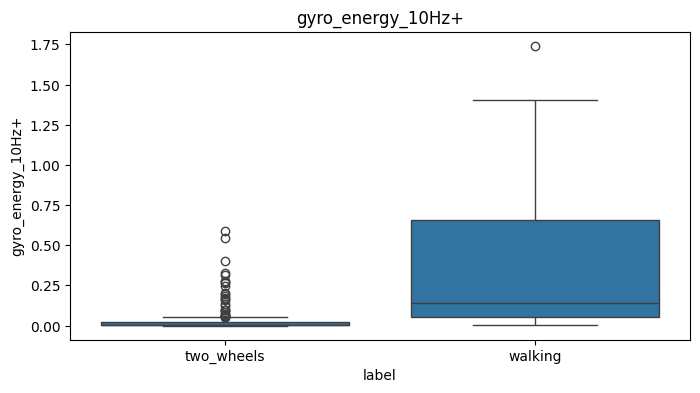

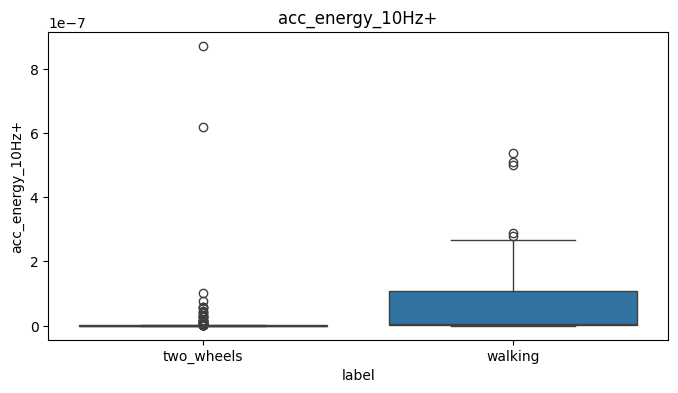

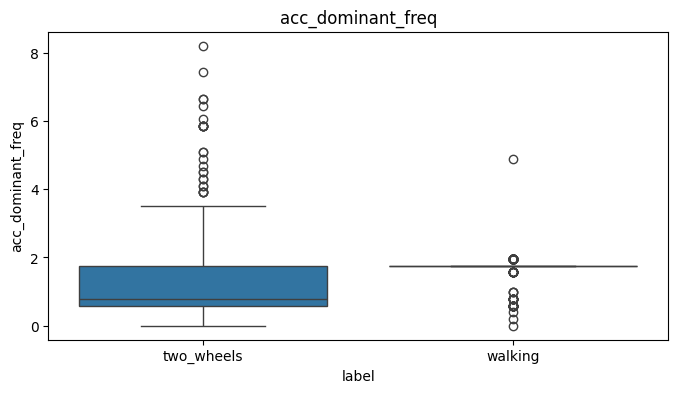

In [130]:
best = [
    "gyro_energy_10Hz+",
    "acc_energy_10Hz+",
    "acc_dominant_freq"
]

for feat in best:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=dataset,
        x="label",
        y=feat
    )

    plt.title(feat)
    plt.show()

## Добавим ещё признаков

In [141]:
for exp in data.values():

    imu = exp["imu"]

    for axis in ["a_x[m/s2]", "a_y[m/s2]", "a_z[m/s2]"]:

        col = axis.replace("[m/s2]", "")

        imu[f"{col}_dyn"] = (
            imu[axis]
            - imu[axis].rolling(
                200,
                center=True,
                min_periods=1
            ).mean()
        )

In [142]:
def signal_features(x, prefix):

    features = {}

    features[f"{prefix}_std"] = np.std(x)
    features[f"{prefix}_rms"] = np.sqrt(np.mean(x**2))
    features[f"{prefix}_range"] = np.ptp(x)
    features[f"{prefix}_skew"] = skew(x)
    features[f"{prefix}_kurtosis"] = kurtosis(x)

    spec = spectral_features(x)

    for k, v in spec.items():
        features[f"{prefix}_{k}"] = v

    return features

In [143]:
def extract_features(window):

    features = {}

    # ==========================
    # norm признаки (старые)
    # ==========================

    acc = window["acc_dyn"].values
    gyro = window["gyro_norm"].values

    features.update(
        signal_features(acc, "acc")
    )

    features.update(
        signal_features(gyro, "gyro")
    )

    # ==========================
    # оси акселерометра
    # ==========================

    features.update(
        signal_features(
            window["a_x_dyn"].values,
            "ax"
        )
    )

    features.update(
        signal_features(
            window["a_y_dyn"].values,
            "ay"
        )
    )

    features.update(
        signal_features(
            window["a_z_dyn"].values,
            "az"
        )
    )

    # ==========================
    # оси гироскопа
    # ==========================

    features.update(
        signal_features(
            window["w_x[rad/s]"].values,
            "wx"
        )
    )

    features.update(
        signal_features(
            window["w_y[rad/s]"].values,
            "wy"
        )
    )

    features.update(
        signal_features(
            window["w_z[rad/s]"].values,
            "wz"
        )
    )

    return features

In [144]:
rows = []

for exp_name, exp in data.items():

    imu = exp["imu"]

    for start in range(
        0,
        len(imu) - WINDOW_SIZE,
        STEP_SIZE
    ):

        stop = start + WINDOW_SIZE

        window = imu.iloc[start:stop]

        feat = extract_features(window)

        feat["experiment"] = exp_name
        feat["label"] = exp["label"]

        rows.append(feat)

dataset = pd.DataFrame(rows)

print(dataset.shape)
dataset.head()

(605, 74)


,acc_std,acc_rms,acc_range,acc_skew,acc_kurtosis,acc_dominant_freq,acc_spectral_energy,acc_energy_1_3Hz,acc_energy_10Hz+,gyro_std,gyro_rms,gyro_range,gyro_skew,gyro_kurtosis,gyro_dominant_freq,gyro_spectral_energy,gyro_energy_1_3Hz,gyro_energy_10Hz+,ax_std,ax_rms,ax_range,ax_skew,ax_kurtosis,ax_dominant_freq,ax_spectral_energy,ax_energy_1_3Hz,ax_energy_10Hz+,ay_std,ay_rms,ay_range,ay_skew,ay_kurtosis,ay_dominant_freq,ay_spectral_energy,ay_energy_1_3Hz,ay_energy_10Hz+,az_std,az_rms,az_range,az_skew,az_kurtosis,az_dominant_freq,az_spectral_energy,az_energy_1_3Hz,az_energy_10Hz+,wx_std,wx_rms,wx_range,wx_skew,wx_kurtosis,wx_dominant_freq,wx_spectral_energy,wx_energy_1_3Hz,wx_energy_10Hz+,wy_std,wy_rms,wy_range,wy_skew,wy_kurtosis,wy_dominant_freq,wy_spectral_energy,wy_energy_1_3Hz,wy_energy_10Hz+,wz_std,wz_rms,wz_range,wz_skew,wz_kurtosis,wz_dominant_freq,wz_spectral_energy,wz_energy_1_3Hz,wz_energy_10Hz+,experiment,label
0,0.001194,0.001194,0.014759,-7.711124,71.758646,1.562500,1.727139e-05,7.359348e-06,8.724000e-07,1.615767,1.976912,14.750258,3.633642,19.164414,0.195312,20.609351,7.203638,0.548196,0.900010,0.901121,6.419113,-0.119150,1.290489,0.195312,5.296699,2.385524,0.009151,0.821785,0.821812,5.073335,-1.305275,4.111248,0.390625,5.958539,0.405522,0.007112,1.280788,1.281352,8.966523,-0.246768,2.288609,0.390625,13.860639,2.199313,0.010199,1.038797,1.058362,9.097053,2.553169,11.188283,0.585938,8.005933,2.893087,0.480380,1.205827,1.226604,15.784797,0.854711,17.234615,1.953125,13.481809,2.846302,1.206903,1.132860,1.132915,15.424213,-5.333914,49.689704,0.390625,14.143075,5.077309,0.526398,motorbike,two_wheels
1,0.001121,0.001122,0.014759,-9.006233,91.824028,0.781250,5.111783e-07,1.494387e-07,1.859654e-08,1.457604,1.740206,14.750258,4.587369,30.244384,0.195312,5.519116,0.549283,0.057713,0.670841,0.675457,6.419113,0.345911,4.686117,0.390625,1.493509,0.358859,0.000211,0.544778,0.544802,4.205914,-1.053684,5.923736,0.390625,0.449833,0.079404,0.000162,1.018199,1.034278,6.442513,0.826982,1.676538,0.195312,4.425205,0.844948,0.001426,0.771565,0.780573,7.141961,1.063979,5.030649,0.781250,3.011959,1.051755,0.127364,1.127394,1.134428,15.784797,0.773502,22.134196,0.390625,4.565975,1.947000,0.081654,1.061102,1.063999,15.424213,-6.554426,66.579861,0.195312,1.431747,0.424558,0.017576,motorbike,two_wheels
2,0.000058,0.000060,0.000772,-0.073003,15.341530,0.195312,1.709718e-08,2.194803e-09,2.315224e-09,0.403166,0.651768,2.772164,1.728747,4.291073,0.390625,1.081147,0.228883,0.038810,0.327751,0.327853,1.873012,0.711084,1.261449,0.390625,0.578198,0.120109,0.000033,0.199317,0.203449,1.181597,0.575741,1.275070,0.390625,0.143007,0.033355,0.000022,0.571403,0.575681,3.590464,-0.515838,2.759026,0.585938,1.014085,0.126818,0.000630,0.398265,0.398357,3.453211,-0.955434,3.999741,2.343750,0.921854,0.391656,0.043454,0.433231,0.437534,3.927125,-0.894897,5.706955,1.953125,1.042317,0.519727,0.015188,0.271017,0.273271,2.506527,0.517851,4.696485,2.734375,0.390781,0.189135,0.003875,motorbike,two_wheels
3,0.000033,0.000033,0.000580,-8.392490,100.922466,0.585938,7.444977e-10,1.524600e-10,4.283942e-11,0.363245,0.626174,2.770693,2.048628,6.880943,0.195312,0.411156,0.091949,0.003905,0.258696,0.258720,1.573568,0.427600,1.235503,0.195312,0.299169,0.047939,0.000024,0.173621,0.173624,1.048032,0.763381,2.074226,0.585938,0.243429,0.013533,0.000005,0.448140,0.448141,2.691578,0.731250,2.168597,0.585938,1.515084,0.036950,0.000077,0.339133,0.339143,3.453211,-0.801447,5.744407,0.585938,0.393431,0.066319,0.004948,0.438963,0.451557,3.927125,-1.142302,5.638483,0.781250,0.659660,0.290738,0.000700,0.269734,0.270504,2.506527,0.773417,5.193597,0.976562,0.169674,0.080124,0.001414,motorbike,two_wheels
4,0.000007,0.000007,0.000058,-2.555049,11.432874,6.640625,3.598563e-10,8.794671e-11,3.415645e-11,0.263427,0.508374,1.563663,1.257522,2.243805,1.367188,0.440201,0.210674,0.004947,0.182870,0.183102,0.983511,0.199609,0.513661,0.195312,0.265757,0.021353,0.000033,0.149028,0.149028,1.048032,1.243614,5.1

In [145]:
print(dataset.shape)

(605, 74)


In [146]:
# пересобрали dataset
dataset = pd.DataFrame(rows)

# заново сформировали X
X = dataset.drop(
    columns=["label", "experiment"]
)

# заново обучили RF
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y_encoded)

# заново вычислили importance
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

In [150]:
print(X.shape)

(605, 72)


In [147]:
logo = LeaveOneGroupOut()

In [149]:
importance.head(30)

,feature,importance
69,wz_spectral_energy,0.073955
28,ay_rms,0.073817
27,ay_std,0.070441
63,wz_std,0.065064
34,ay_energy_1_3Hz,0.063440
33,ay_spectral_energy,0.050016
64,wz_rms,0.040292
62,wy_energy_10Hz+,0.036916
45,wx_std,0.034151
17,gyro_energy_10Hz+,0.033733


In [152]:
scores = []

for train_idx, test_idx in logo.split(
    X,
    y_encoded,
    groups
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y_encoded[train_idx]
    y_test = y_encoded[test_idx]

    test_exp = groups.iloc[test_idx].iloc[0]

    clf = RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )

    clf.fit(X_train, y_train)

    pred = clf.predict(X_test)

    acc = accuracy_score(
        y_test,
        pred
    )

    scores.append(acc)

    print(
        f"{test_exp:15s} "
        f"accuracy = {acc:.3f}"
    )

    cm = confusion_matrix(
    y_test,
    pred,
    labels=[0, 1]
    )

    print(test_exp)
    print(cm)
    print('------------------------')

print()
print("Mean accuracy =", np.mean(scores))
print("Std accuracy  =", np.std(scores))

bicycle         accuracy = 0.619
bicycle
[[73 45]
 [ 0  0]]
------------------------
handphone_1     accuracy = 1.000
handphone_1
[[ 0  0]
 [ 0 87]]
------------------------
handphone_2     accuracy = 0.920
handphone_2
[[ 0  0]
 [ 7 81]]
------------------------
motorbike       accuracy = 1.000
motorbike
[[135   0]
 [  0   0]]
------------------------
pocketphone_1   accuracy = 1.000
pocketphone_1
[[ 0  0]
 [ 0 88]]
------------------------
pocketphone_2   accuracy = 0.955
pocketphone_2
[[ 0  0]
 [ 4 85]]
------------------------

Mean accuracy = 0.9156924655044061
Std accuracy  = 0.13609629624252378


### PCA

In [155]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [156]:
pca_df = pd.DataFrame({
    "pc1": X_pca[:,0],
    "pc2": X_pca[:,1],
    "label": dataset["label"],
    "experiment": dataset["experiment"]
})

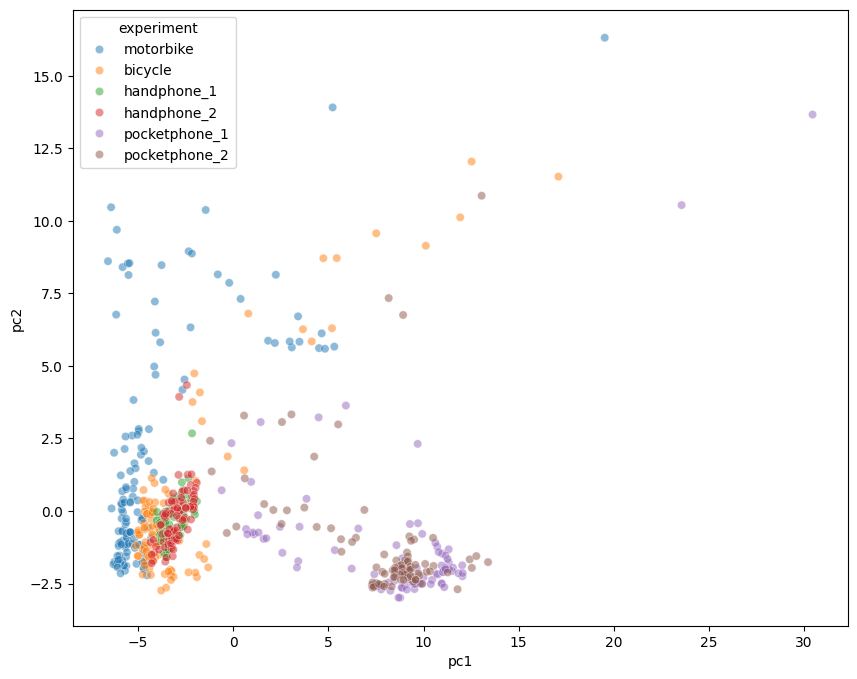

In [157]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="pc1",
    y="pc2",
    hue="experiment",
    alpha=0.5
)

plt.show()